# London Bicycles Data Analysis

Name: SeokEng Tay  
Module: NTU Module 2 Data Engineering Project  

## Objective
Analyze the London bicycle dataset from the data warehouse to identify
usage patterns and generate business insights.

## Introduction

This notebook analyzes the London bike sharing dataset stored in Google BigQuery.
The goal is to identify usage patterns and derive insights that could help improve
bike allocation and operational planning for the bike sharing system.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [23]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

In [24]:
!pip install google-cloud-bigquery pandas

In [25]:
from google.cloud import bigquery
import pandas as pd

In [26]:
client = bigquery.Client()

In [27]:
for dataset in client.list_datasets():
    print(dataset.dataset_id)

austin_bikeshare_demo
austin_bikeshare_demo_star
ingestion
liquor_demo
liquor_demo_star
london_bicycles
london_bicycles_star
resale
snapshots


In [28]:
print(client.project)

dsai-module2-gc-4339


In [29]:
for table in client.list_tables("london_bicycles_star"):
    print(table.table_id)

dim_bike
dim_date
dim_station
fact_bike_daily_usage
fact_hire


# First Analysis — Rentals by Day of Week
Weekdays are usually higher because of commuters.

In [73]:
query = """
SELECT
    d.day_of_week,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_date` d
ON f.start_date_key = d.date_key
GROUP BY d.day_of_week
ORDER BY total_rides DESC
"""

df_day = client.query(query).to_dataframe()

df_day

,day_of_week,total_rides
0,4,12677140
1,2,12615271
2,3,12593822
3,5,12199553
4,1,11709564
5,6,11287348
6,7,10332568


# Interpretation

day_of_week numbers correspond to the dim_date table convention:
1 → Monday
2 → Tuesday
3 → Wednesday
4 → Thursday
5 → Friday
6 → Saturday
7 → Sunday
total_rides is the total number of bike rentals starting on that day of the week across the dataset.

Thursday (4) has the highest rentals → 12.68M rides
Friday (5), Wednesday (3), and Tuesday (2) are also very busy → typical weekday commuting pattern
Weekends (6 = Saturday, 7 = Sunday) have lower rentals → mostly recreational or casual rides
Monday (1) is lower than midweek → could reflect shorter commuting or delayed starts

Key insight: Bike-sharing usage is heavily weekday-driven, peaking midweek (Tuesday–Thursday), and dips on weekends

In [65]:
print(df_day)
print(df_day.dtypes)

  day_of_week  total_rides day_name
0           4     12677140      NaN
1           2     12615271      NaN
2           3     12593822      NaN
3           5     12199553      NaN
4           1     11709564      NaN
5           6     11287348      NaN
6           7     10332568      NaN
day_of_week      object
total_rides       Int64
day_name       category
dtype: object


# Visualization

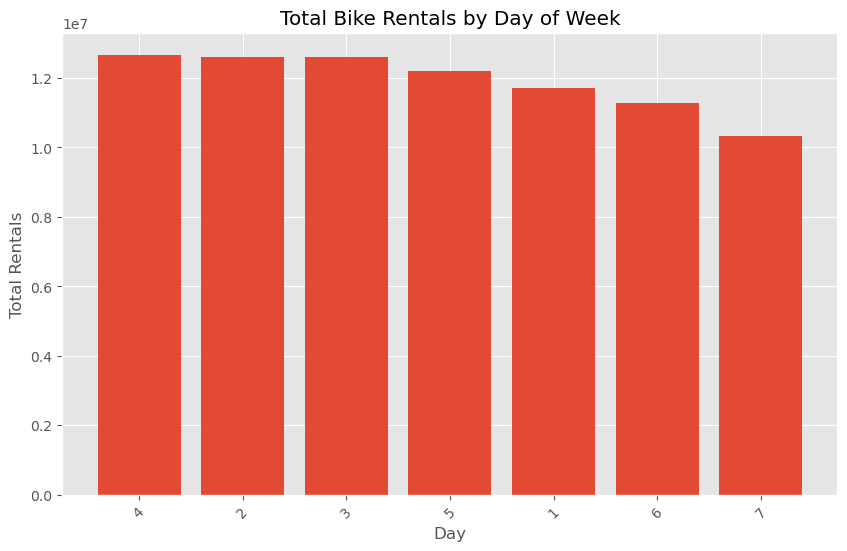

In [74]:
import matplotlib.pyplot as plt

plt.bar(df_day["day_of_week"], df_day["total_rides"])

plt.title("Total Bike Rentals by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Rentals")

plt.xticks(rotation=45)
plt.show()

### Business Insight

Weekday rentals are higher than weekend rentals, suggesting the bike-sharing system is widely used for commuting rather than leisure activities. Transport operators can ensure more bikes
are available during weekday peak hours to meet demand.

# Second Analysis — Bike Rentals by Hour

Use the fact table fact_hire.

In [78]:
query = """
SELECT
    start_hour,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY start_hour
ORDER BY start_hour
"""

df_hour = client.query(query).to_dataframe()

df_hour

,start_hour,total_rides
0,0,866425
1,1,569113
2,2,367047
3,3,252428
4,4,206294
5,5,339881
6,6,1428647
7,7,4105422
8,8,7568476
9,9,4668512


In [30]:
query = """
SELECT
    EXTRACT(HOUR FROM start_date) AS hour,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY hour
ORDER BY hour
"""

df = client.query(query).to_dataframe()

df.head()

,hour,total_rides
0,0,866425
1,1,569113
2,2,367047
3,3,252428
4,4,206294


### Visualization

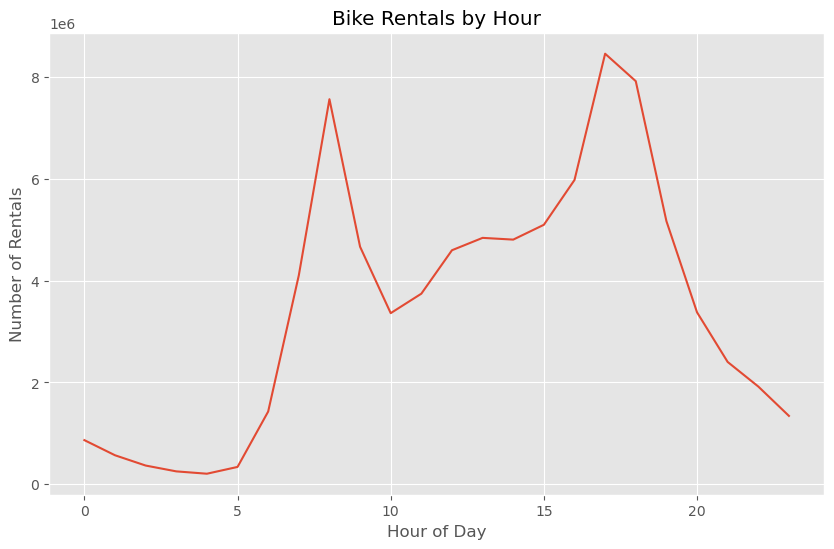

In [50]:
import matplotlib.pyplot as plt

plt.plot(df["hour"], df["total_rides"])

plt.title("Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rentals")

plt.show()

#Bike rentals by hour of day → reveals commuting peaks (8 AM & 6 PM).
SQL Query — Bike Rentals by Hour

will usually see two peaks:
Morning commute (~8 AM)
Evening commute (~5–6 PM)

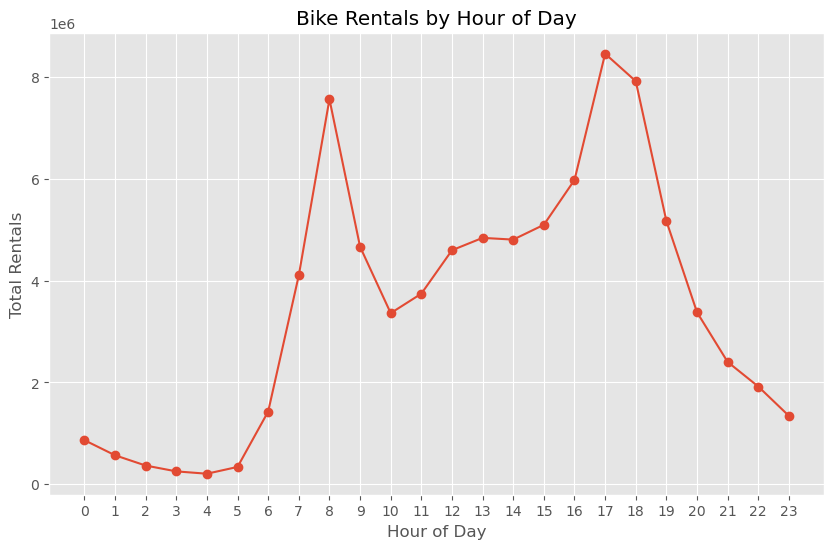

In [79]:
# Visualization

import matplotlib.pyplot as plt

plt.plot(df_hour["start_hour"], df_hour["total_rides"], marker='o')

plt.title("Bike Rentals by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Rentals")

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

### Business Insight

Bike rental demand peaks during morning and evening hours, indicating strong commuter usage of the London bike-sharing system.

# Third Analysis   — Most Popular Stations
This uses fact + dimension

In [51]:
query = """
SELECT
    s.station_name,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_station` s
ON f.start_station_id = s.station_id
GROUP BY s.station_name
ORDER BY total_rides DESC
LIMIT 10
"""

df_station = client.query(query).to_dataframe()

df_station

,station_name,total_rides
0,"Hyde Park Corner, Hyde Park",671389
1,"Belgrove Street , King's Cross",592919
2,"Waterloo Station 3, Waterloo",527018
3,"Albert Gate, Hyde Park",460887
4,"Black Lion Gate, Kensington Gardens",459513
5,"Waterloo Station 1, Waterloo",419231
6,"Wellington Arch, Hyde Park",392741
7,"Hop Exchange, The Borough",385830
8,"Exhibition Road, South Kensington",384177
9,"Exhibition Road Museums, Knightsbridge",384177


# Third Analysis   — Most Popular Stations
This uses fact + dimension

In [76]:
query = """
SELECT
    s.station_name,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_station` s
ON f.start_station_id = s.station_id
GROUP BY s.station_name
ORDER BY total_rides DESC
LIMIT 10
"""

df_station = client.query(query).to_dataframe()

df_station

,station_name,total_rides
0,"Hyde Park Corner, Hyde Park",671389
1,"Belgrove Street , King's Cross",592919
2,"Waterloo Station 3, Waterloo",527018
3,"Albert Gate, Hyde Park",460887
4,"Black Lion Gate, Kensington Gardens",459513
5,"Waterloo Station 1, Waterloo",419231
6,"Wellington Arch, Hyde Park",392741
7,"Hop Exchange, The Borough",385830
8,"Exhibition Road, South Kensington",384177
9,"Exhibition Road Museums, Knightsbridge",384177


At this point notebook demonstrates:

BigQuery connection
Star schema tables
Fact + dimension join
SQL analytics
Visualization
Business insight

#SQL Query – Top 10 Start Stations
This joins fact_hire with dim_station using start_station_id.

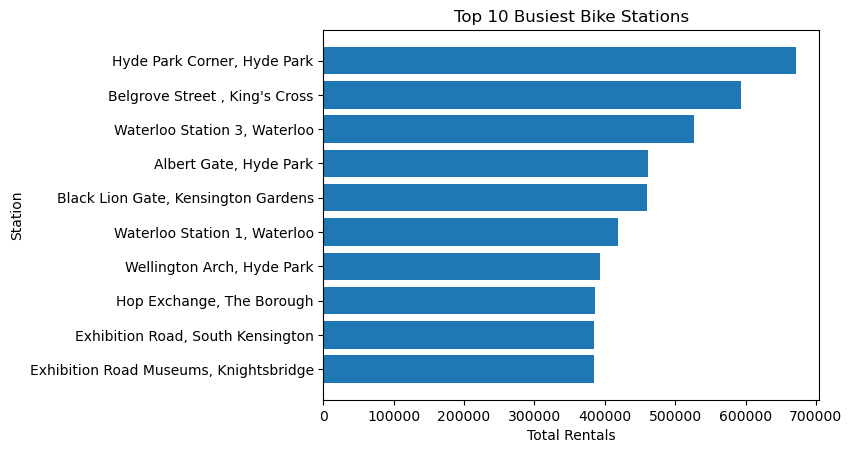

In [ ]:
import matplotlib.pyplot as plt

plt.barh(df_station["station_name"], df_station["total_rides"])

plt.title("Top 10 Busiest Bike Stations")
plt.xlabel("Total Rentals")
plt.ylabel("Station")

plt.gca().invert_yaxis()
plt.show()

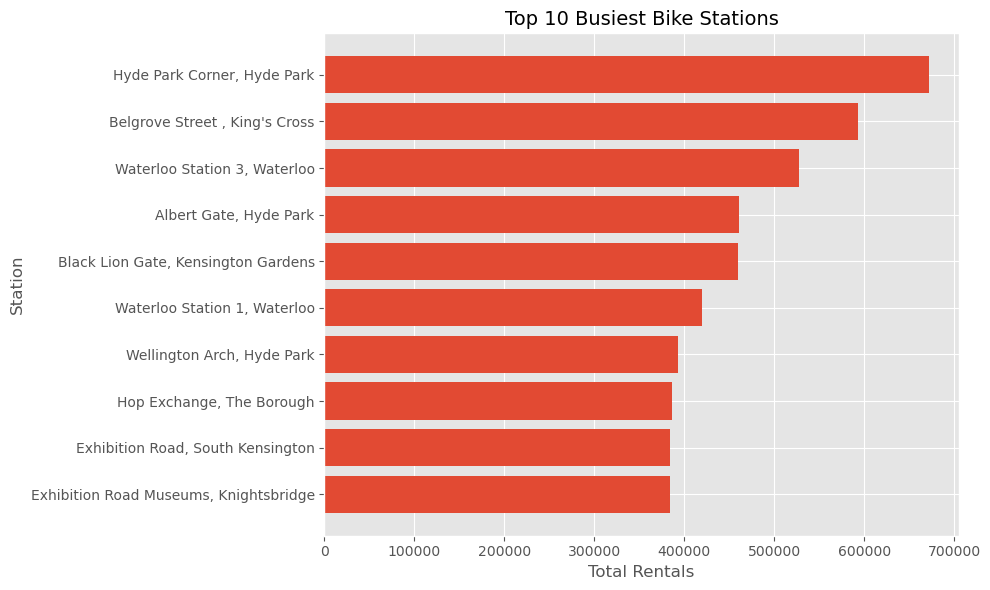

In [ ]:
plt.barh(df_station["station_name"], df_station["total_rides"])

plt.title("Top 10 Busiest Bike Stations", fontsize=14)
plt.xlabel("Total Rentals")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Business Insight

The busiest stations are located near major transport hubs and business districts.
This suggests that users frequently combine bike sharing with public transport
for commuting. Increasing bike availability at these stations during peak hours
could improve service efficiency.

Analysis includes:

✅ Fact table analytics
✅ Dimension table joins
✅ Star schema usage
✅ SQL in BigQuery
✅ Python visualization with Pandas & Matplotlib
✅ Business interpretation

Bike rentals peak during the morning (around 8 AM) and evening (around 5–6 PM).
This pattern suggests the bike sharing system is widely used for commuting.
Operators should ensure sufficient bike availability during these peak hours
to maintain service reliability.

 Now have three solid analyses:

1️⃣ Rentals by Day of Week
Shows weekday vs weekend behavior.
2️⃣ Rentals by Hour
Shows commuting peak demand.
3️⃣ Top 10 Busiest Stations
Uses fact + dimension join.

These three together demonstrate:

✔ SQL analytics
✔ Star schema understanding
✔ BigQuery usage
✔ Python visualization
✔ Business insights

#SQL Query — Peak vs Off-Peak Rentals

We classify hours into Peak and Off-Peak.

In [80]:
query = """
SELECT
    CASE
        WHEN start_hour BETWEEN 7 AND 9 THEN 'Morning Peak'
        WHEN start_hour BETWEEN 17 AND 19 THEN 'Evening Peak'
        ELSE 'Off-Peak'
    END AS time_period,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY time_period
ORDER BY total_rides DESC
"""

df_peak = client.query(query).to_dataframe()

df_peak

,time_period,total_rides
0,Off-Peak,45514071
1,Evening Peak,21558785
2,Morning Peak,16342410


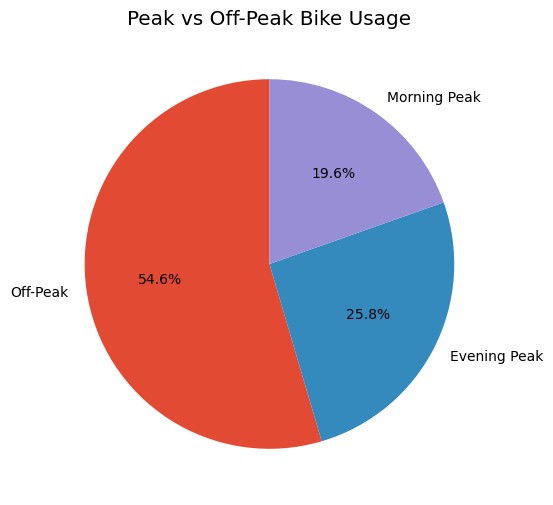

In [81]:
# Visualization
import matplotlib.pyplot as plt

plt.pie(
    df_peak["total_rides"],
    labels=df_peak["time_period"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Peak vs Off-Peak Bike Usage")

plt.show()

### Business Insight

Peak usage occurs during morning and evening commuting hours.
This indicates strong demand for bike sharing as a first-mile
and last-mile transport solution.

Operators should prioritize bike availability and redistribution
during these peak periods to reduce shortages and improve service quality.

4 Analyses
1️⃣ Rentals by Day of Week
2️⃣ Rentals by Hour of Day
3️⃣ Top 10 Busiest Stations
4️⃣ Peak vs Off-Peak Usage

Together they show:

✔ Temporal patterns
✔ Location demand
✔ Operational insights



## Final Summary Insights

From the analysis of the London bike sharing dataset, several key patterns emerge:

• **Weekday usage is higher than weekends**  
  This indicates that many users rely on the bike-sharing system for daily commuting rather than recreational rides.

• **Demand peaks during commuting hours**  
  Rentals are highest around **8 AM and 5–6 PM**, reflecting typical work travel patterns.

• **Certain stations experience significantly higher traffic**  
  Stations near **major transport hubs and business districts** are the busiest, suggesting integration with public transport.

• **Peak vs Off-Peak Usage Patterns** 
  Peak periods (commute hours) see high frequency of rentals and require careful bike redistribution.

  Off-peak periods (late morning, early afternoon, late evening) have lower demand, offering opportunities for maintenance, bike repositioning, and promotion of casual leisure rides.

• **Operational recommendation**  
  Bike operators should prioritize **bike redistribution and availability during weekday peak hours and at high-demand stations** while leveraging off-peak times for maintenance and targeted promotions to improve overall service efficiency and customer satisfaction.

Notebook Structure  
1️⃣ Introduction
Explain the dataset and goal.

2️⃣ Data Exploration
Preview tables from BigQuery.

4 Analyses
1️⃣ Rentals by Day of Week
2️⃣ Rentals by Hour of Day
3️⃣ Top 10 Busiest Stations
4️⃣ Peak vs Off-Peak Usage

6️⃣ Visualization

7️⃣ Final Business Insights (the summary above)